<a href="https://colab.research.google.com/github/RasinduHansaka/Labs_DL/blob/Lab01/Lab01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Required libraries
!pip install seaborn pandas matplotlib numpy --quiet

#  Required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For 3D plots
from mpl_toolkits.mplot3d import Axes3D

4x4 Array from exponential distribution:
 [[0.18288714 0.30718868 0.55752267 0.73399527]
 [1.01766085 0.12264046 0.28088695 0.89430201]
 [0.2360928  1.94909111 0.68383759 0.64200314]
 [0.9814754  0.451227   2.19529675 1.75870585]]


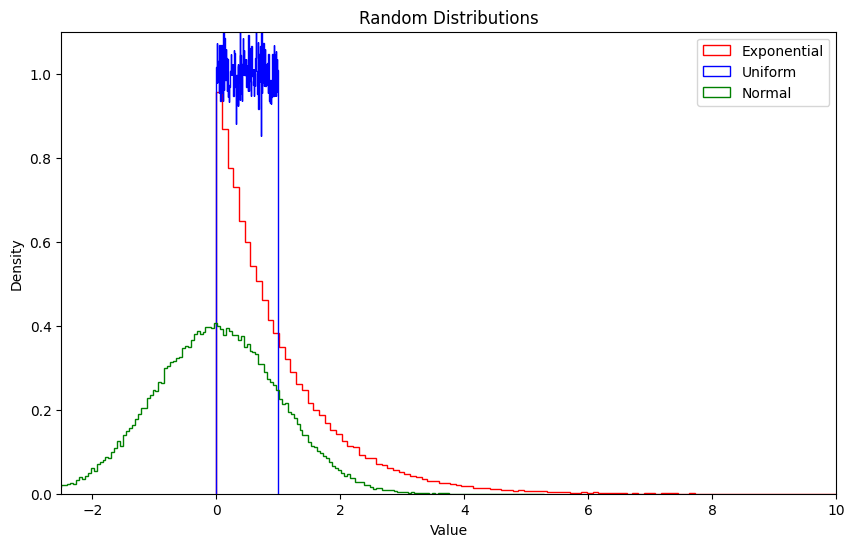

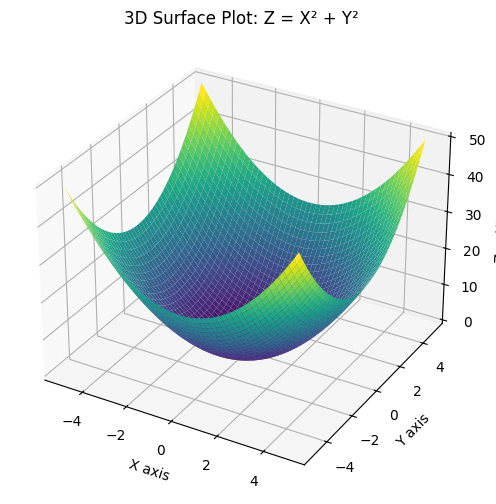

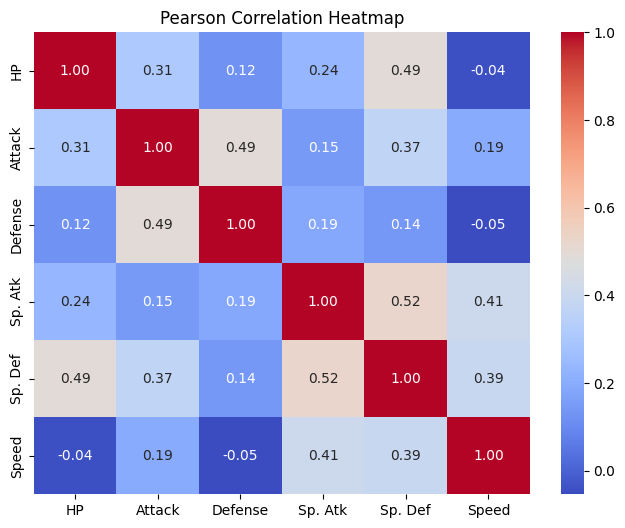

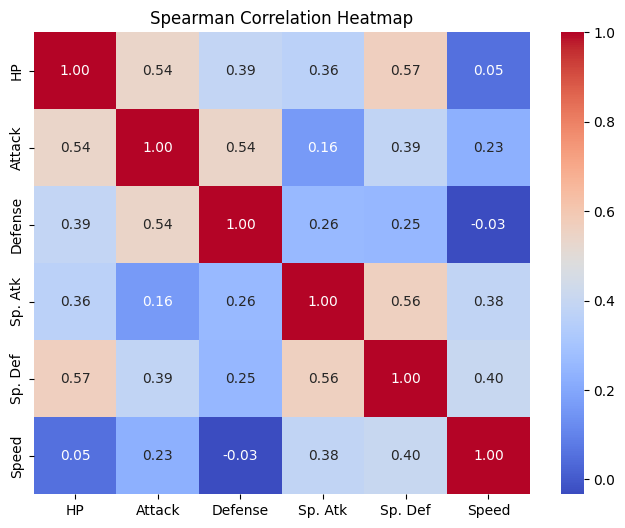

In [10]:
# Create a 4x4 array from exponential distribution with lambda=1
arr_4x4 = np.random.exponential(scale=1.0, size=(4, 4))
print("4x4 Array from exponential distribution:\n", arr_4x4)


# Random 100000x1 from exponential
exp_data = np.random.exponential(scale=1.0, size=(100000, 1))
uniform_data = np.random.rand(100000)  # uniform [0,1]
normal_data = np.random.randn(100000)  # standard normal

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(exp_data, density=True, bins=200, histtype="step", color="red", label="Exponential")
plt.hist(uniform_data, density=True, bins=200, histtype="step", color="blue", label="Uniform")
plt.hist(normal_data, density=True, bins=200, histtype="step", color="green", label="Normal")

plt.axis([-2.5, 10, 0, 1.1])
plt.legend(loc="upper right")
plt.title("Random Distributions")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

# Create meshgrid for X, Y in range [-5, 5]
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

# 3D plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')

ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z = X² + Y²")
plt.title("3D Surface Plot: Z = X² + Y²")
plt.show()




# Load  dataset
df = pd.read_csv("Pokemon.csv", encoding='latin1')

# Select exactly matching feature names
features = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]
df_features = df[features].dropna()

# Pearson correlation
pearson_corr = df_features.corr(method='pearson')

# Spearman correlation
spearman_corr = df_features.corr(method='spearman')

# Pearson heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation Heatmap")
plt.show()

# Spearman heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation Heatmap")
plt.show()



First 20 samples:
    N_total  N_bulk  N_surface    R_avg
0      1599    1014        585  17.3706
1      1642    1034        608  17.6061
2      4637    3365       1272  25.3692
3      7189    5292       1897  29.7011
4     11004    8508       2496  34.2831
5     13375   10768       2607  36.6334
6     13795   11155       2640  37.0108
7     13947   11304       2643  37.1672
8     14020   11357       2663  37.2103
9     14056   11389       2667  37.2467
10     1534     966        568  17.1107
11     1559     974        585  17.2101
12     4356    3099       1257  24.8253
13     6550    4675       1875  29.0376
14    10175    7748       2427  33.4399
15    12393    9842       2551  35.6950
16    13207   10590       2617  36.4657
17    13543   10937       2606  36.7871
18    13713   11079       2634  36.9333
19    13791   11151       2640  37.0104

Mean values:
N_total      3476.786500
N_bulk       2521.550250
N_surface     955.236250
R_avg          20.654363
dtype: float64

Standard dev

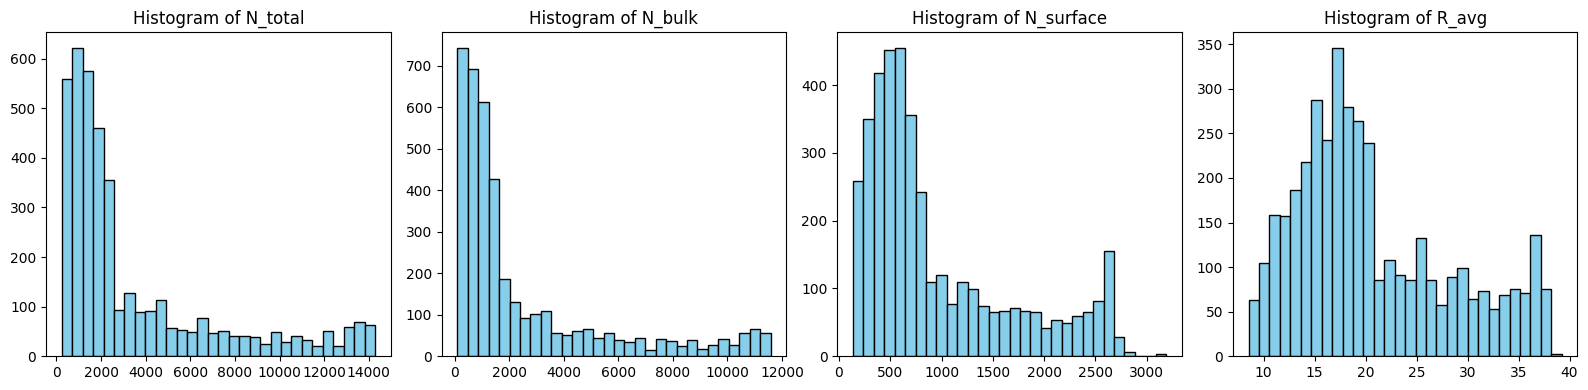

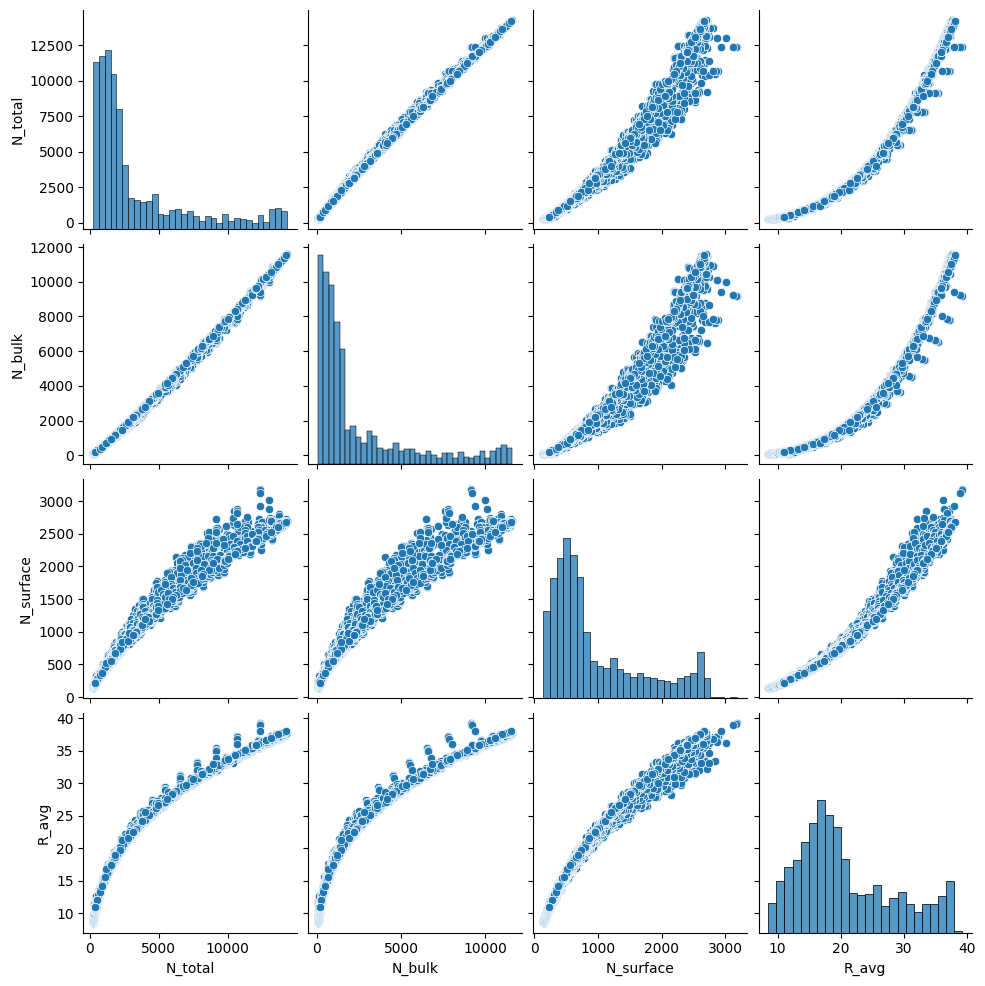

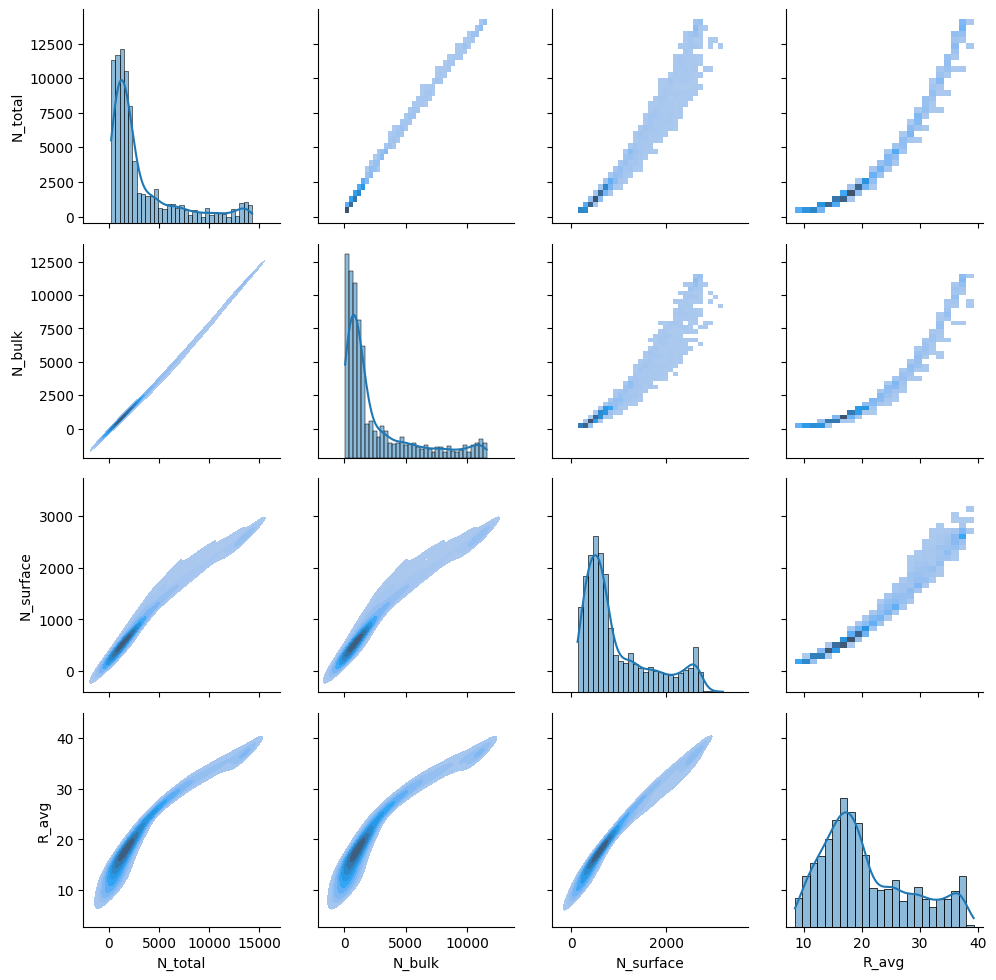

In [14]:

# 1. Load dataset
df_au = pd.read_csv("Au_nanoparticle_dataset.csv")

# Create new dataframe with only specified columns
new_df = df_au[["N_total", "N_bulk", "N_surface", "R_avg"]]

# 2. Display first 20 samples
print("First 20 samples:")
print(new_df.head(20))

# 3. Calculate mean, standard deviation, and quartiles explicitly
print("\nMean values:")
print(new_df.mean())

print("\nStandard deviation values:")
print(new_df.std())

print("\nQuartile values (25%, 50%, 75%):")
print(new_df.quantile([0.25, 0.5, 0.75]))

# 4. Histogram of each feature in a 1x4 layout
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(new_df.columns):
    axes[i].hist(new_df[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

# 5. Pairplot with scatter and histograms
sns.pairplot(new_df)
plt.show()

# 6. Customized PairGrid
# a. Diagonal: histogram + KDE
# b. Lower half: bivariate KDE plot
g = sns.PairGrid(new_df)
g.map_upper(sns.histplot)  # Bivariate histogram
g.map_diag(sns.histplot, kde=True)  # Histogram + KDE on diagonal
g.map_lower(sns.kdeplot, fill=True)  # Bivariate KDE on lower half
plt.show()